# Binary Transformers on MNISTBinary transformer models for MNIST classification.

In [1]:
# Transformers as autoregressive models

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM


In [6]:
# MNIST data
import numpy as np
from datasets import load_dataset

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [7]:
train_data = dataset["train"]

In [8]:
train_data[np.arange(10)]["image"].shape

(10, 28, 28)

In [55]:
def train_data_generator(batch_size=64):
    while True:
        idx = np.random.randint(0,len(train_data), size=batch_size)
        xs_batch = jnp.array(train_data[idx]["image"] > 90, dtype=jnp.int32).reshape(batch_size, 28*28)
        yield xs_batch

datagenerator = train_data_generator()

In [83]:
key = jrandom.PRNGKey(0)

VOCAB_SIZE = 2
MAX_LEN = 784

In [201]:
class Model(nnx.Module):

    num_heads: int = 4
    num_layers: int = 8
    dim: int
    widening_factor: int = 2
    attn_size: int = 20

    def __init__(self, dim,rngs, dropout_rate=None):
        self.embed = nnx.Embed(2, dim, rngs=rngs)
        self.pos_embed = PosEmbed(dim,rngs=rngs)
        self.transformer = Transformer(dim, self.num_heads,self.num_heads,self.attn_size, widening_factor=self.widening_factor,rngs=rngs, dropout_rate=dropout_rate)
        self.output = nnx.Linear(dim, 1, rngs=rngs)
        self.start_token = nnx.Param(jnp.zeros((1,dim)))

    def __call__(self, x, decode=False, deterministic=False):
        x = self.embed(x)
        x = self.pos_embed(x)
        # Autoregressive mask 
        start_token = self.start_token.value
        start_token = jnp.repeat(start_token[None,...], x.shape[0], axis=0)
        x = jnp.concatenate([start_token, x], axis=1)
        mask = jnp.tril(jnp.ones((x.shape[-2], x.shape[-2])))
        x = self.transformer(x, mask=mask, deterministic=deterministic, decode=decode)
        logits = self.output(x)
        return logits[:, :-1, :]



In [202]:
model = Model(50,rngs=nnx.Rngs(0))

In [203]:
params = nnx.state(model, nnx.Param)

In [204]:
optimizer = optax.chain(optax.adaptive_grad_clip(10.),optax.adamw(1e-4))
opt_state = optimizer.init(params)

In [205]:

def loss_fn(params, inputs):
    nnx.update(model, params)
    logits = model(inputs)
    logits = logits.squeeze(-1)
    inp_data = inputs.astype(jnp.float32)
    loss = optax.sigmoid_binary_cross_entropy(logits, inp_data)
    return jnp.mean(loss)

@jax.jit
def update(params, inputs,opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, inputs)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [ ]:

for i in range(10):
    l = 0
    count = 0
    for i in range(100):
        inputs = next(datagenerator)
        loss, params, opt_state = update(params, inputs,opt_state)
        l += loss
        count += 1

    print(l/count)

2024-11-10 15:29:56.026253: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 601.78MiB (rounded to 631014400)requested by op 
2024-11-10 15:29:56.027822: W external/xla/xla/tsl/framework/bfc_allocator.cc:508] ***************************************************************************************************_


In [165]:

for i in range(10):
    l = 0
    count = 0
    for i in range(1000):
        inputs = next(datagenerator)
        loss, params, opt_state = update(params, inputs,opt_state)
        l += loss
        count += 1

    print(l/count)

0.08675543
0.08028976
0.077634744


KeyboardInterrupt: 

In [166]:
nnx.update(model, params)

In [167]:
inputs = next(datagenerator)

In [168]:
logits = model(inputs[:1,:500])

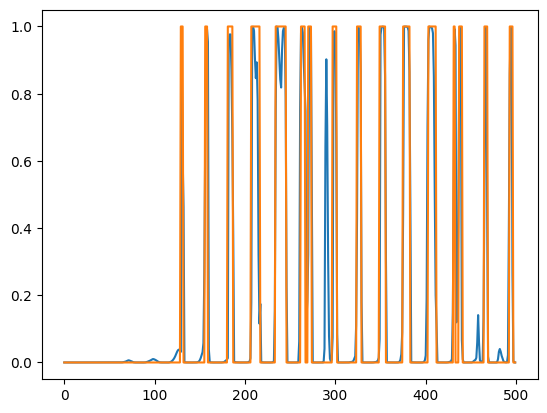

In [169]:
plt.plot(jax.nn.sigmoid(logits).flatten())
plt.plot(inputs[:1,:500].flatten())

In [170]:

def naive_autoregressive_decoding(key, T=784):
    x = jnp.zeros((1, T), dtype=jnp.bool_)
    def scan_fn(carry, k):
        x, i = carry
        logits = model(x.astype(jnp.int32))
        p_i = jax.nn.sigmoid(logits[0,i]).squeeze(-1)
        #jax.debug.print("p={p}", p=p_i)
        x_i = jax.random.bernoulli(k, p_i)
        x = x.at[0, i].set(x_i)
        return (x, i+1), None
    keys = jrandom.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)

    return x[0].squeeze(0)

In [171]:
keys = jrandom.split(jrandom.PRNGKey(0), 100)

In [172]:
samples = jax.vmap(naive_autoregressive_decoding)(keys)

In [173]:
img = samples.reshape(10, 10, 28, 28).transpose(0, 2, 1, 3).reshape(10*28, 10*28)

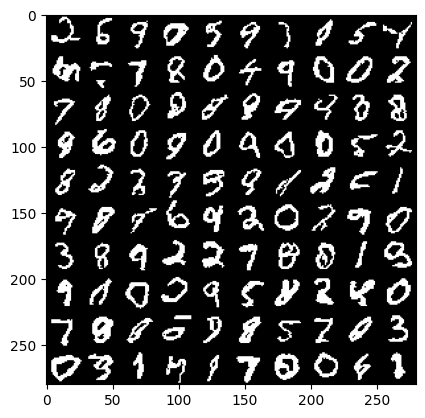

In [174]:
plt.imshow(img, cmap="gray")